# Notebook 04 — Automated Data Pipeline Validation

Runs `src.data_pipeline.auto_fetch` end-to-end and reports success / warning indicators before training.

In [1]:
import os
import sys
from pathlib import Path

repo = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
while not (repo / "src").exists():
    repo = repo.parent
sys.path.insert(0, str(repo))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data_pipeline import auto_fetch, fetch_to_pyg, validate_transactions

USE_HF = False  # set True to fetch from Hugging Face
src = None if USE_HF else "synthetic"
print(f"dataset source: {src}")

ModuleNotFoundError: No module named 'matplotlib'

## Stage 1 — fetch

In [ ]:
df, stats = auto_fetch(hf_query=None if src == "synthetic" else "qubit420/ibm-aml-LI-smaller")
print(f"rows={stats['rows']:,} provenance={stats['provenance']}")

[2026-08-28 13:02:01,907] [INFO] [src.data_pipeline.ingestion] Generated 6000 synthetic transactions over 400 accounts (2.00% flagged)


[2026-08-28 13:02:01,915] [INFO] [src.data_pipeline.auto_fetch] sanitized_transactions


[2026-08-28 13:02:01,929] [INFO] [src.data_pipeline.auto_fetch] auto_fetch_complete


rows=6,000 provenance=synthetic


## Stage 2 — validate (null checks, topology, imbalance)

In [ ]:
hard_checks = {
    "no_nulls": stats["null_cells"] == 0,
    "non_empty_nodes": stats["nodes"] > 0,
    "non_empty_edges": stats["edges"] > 0,
    "aml_ratio_visible": 0 < stats["aml_ratio"] < 1,
}
soft_checks = {
    "single_component": stats["connected_components"] == 1,
}
for k, ok in hard_checks.items():
    print(f"{'✅' if ok else '⚠️'} {k}")
for k, ok in soft_checks.items():
    print(f"{'⚠️ (warning)' if not ok else '✅'} {k}")
assert all(hard_checks.values()), "hard validation failed"
print(
    {
        "connected_components": stats["connected_components"],
        "rows": stats["rows"],
        "nodes": stats["nodes"],
        "aml_ratio": stats["aml_ratio"],
    }
)

✅ no_nulls
✅ non_empty_nodes
✅ non_empty_edges
✅ aml_ratio_visible
⚠️ (warning) single_component
{'connected_components': 2, 'rows': 6000, 'nodes': 400, 'aml_ratio': 0.08}


## Stage 3 — PyG conversion

In [ ]:
data, gstats = fetch_to_pyg(hf_query=None if src == "synthetic" else "qubit420/ibm-aml-LI-smaller")
print(f"nodes={data.num_nodes:,} edges={data.num_edges:,} features={gstats['num_node_features']}")

[2026-08-28 13:02:02,018] [INFO] [src.data_pipeline.ingestion] Generated 6000 synthetic transactions over 400 accounts (2.00% flagged)


[2026-08-28 13:02:02,023] [INFO] [src.data_pipeline.auto_fetch] sanitized_transactions


[2026-08-28 13:02:02,037] [INFO] [src.data_pipeline.auto_fetch] auto_fetch_complete


[2026-08-28 13:02:02,060] [INFO] [src.data_pipeline.graph_builder] Built graph: 400 nodes, 6000 edges, 9 node features, 2 edge features


nodes=400 edges=6,000 features=9


## Stage 4 — visual summary

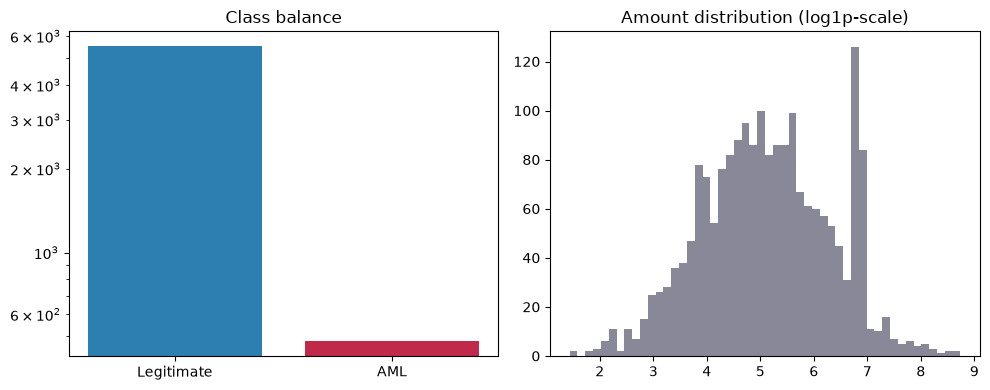

{'rows': 6000, 'nodes': 400, 'edges': 6000, 'avg_degree': 15.0, 'connected_components': 2, 'class_counts': {0: 5520, 1: 480}, 'aml_ratio': 0.08, 'null_cells': 0, 'provenance': 'synthetic', 'normalized_amounts': True}


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(
    ["Legitimate", "AML"],
    [stats["class_counts"][0], stats["class_counts"][1]],
    color=["#2c7fb0", "#c1294b"],
)
axes[0].set_yscale("log")
axes[0].set_title("Class balance")
amount_sample = df["amount"].sample(min(2000, len(df)), random_state=0)
axes[1].hist(amount_sample, bins=50, color="#889")
axes[1].set_title("Amount distribution (log1p-scale)")
plt.tight_layout()
plt.show()
print(stats)